## Data Analysis & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 100)

### Scientific Grouping of Variables

The 126 variables in the Master Sheet are organized into meaningful analytical groups based on their role in the sugarcane study.

The grouping is based on scientific meaning rather than only data type. This will help select appropriate variables for descriptive statistics, visualization, correlation analysis, stress analysis, and later predictive modelling.

In [9]:
variable_groups = {
    "1. Plot and Location": [
        "Plot_ID",
        "Village_registry",
        "Block_registry",
        "Season_registry",
        "Latitude_deg",
        "Longitude_deg",
        "Plot_Area_ha",
        "Irrigation_type",
        "Soil_type"
    ],
    "2. Crop and Cultivation": [
        "Planting_date",
        "Harvest_date",
        "Growth_days",
        "Village_tsh",
        "Season_tsh",
        "Cultivar",
        "Cycle",
        "Block_tsh",
        "Mill_ID"
    ],
    "3. Yield and Sugar Quality": [
        "TCH_t_per_ha",
        "CCS_pct",
        "TSH_t_per_ha",
        "Sugar_recovery_pct",
        "Juice_purity_pct",
        "Brix_pct",
        "Pol_pct"
    ],
    "4. Weather and Precipitation": [
        "Village",
        "Season",
        "Source",
        "Grid_lat",
        "Grid_lon",
        "Precip_growth_phase_mm",
        "Precip_Jun_Aug_mm",
        "Precip_Sep_Nov_mm",
        "Precip_Dec_Feb_mm",
        "Dry_spell_days_gt5",
        "Wet_days_gt10mm",
        "Max_1day_precip_mm",
        "Drought_flag",
        "Excess_rain_flag",
        "SPI_3month"
    ],
    "5. Nitrogen": [
        "Village_N",
        "Season_N",
        "Sample date",
        "Growth stage",
        "Leaf position",
        "N content pct DW",
        "N class",
        "Kjeldahl N mg kg",
        "Total protein pct",
        "Chlorophyll SPAD",
        "N fertiliser kg ha",
        "Method",
        "Lab ID"
    ],
    "6. Phosphorus": [
        "Village_P",
        "Season_P",
        "Sample date_P",
        "Growth stage_P",
        "P content pct DW",
        "P class",
        "P mg per kg DW",
        "P2O5 pct",
        "Available P Olsen",
        "P fertiliser kg ha",
        "P uptake kg ha",
        "Method_P",
        "Lab ID_P"
    ],
    "7. Potassium": [
        "Village_K",
        "Season_K",
        "Sample date_K",
        "Growth stage_K",
        "K content pct DW",
        "K class",
        "K mg per kg DW",
        "K2O pct",
        "Exchangeable K meq",
        "K fertiliser kg ha",
        "K Na ratio",
        "Method_K",
        "Lab ID_K"
    ],
    "8. Vegetation and Spectral Indices": [
        "Village_GNDVI",
        "Season_GNDVI",
        "Acquisition date",
        "Growth stage_GNDVI",
        "GNDVI",
        "GNDVI class",
        "NDVI",
        "EVI",
        "LSWI",
        "Canopy LAI est",
        "Chlorophyll est ug cm2",
        "Formula",
        "Source dataset"
    ],
    "9. Chlorophyll and Physiological Variables": [
        "Village_CHL",
        "Cultivar_CHL",
        "Cycle_CHL",
        "Season_CHL",
        "Block",
        "Sample date_CHL",
        "Time of sampling",
        "Growth stage_CHL",
        "Leaf position_CHL",
        "Leaf age days",
        "Chl a mg per gFW",
        "Chl b mg per gFW",
        "Total Chl mg per gFW",
        "Chl a to b ratio",
        "Carotenoid mg per gFW",
        "Chl to Carotenoid ratio",
        "SPAD value",
        "Chlorophyll Index CI",
        "Pheophytin mg per gFW",
        "Chl degradation pct",
        "Fv Fm PSII efficiency",
        "Phi PSII quantum yield",
        "NPQ non photochem quenching",
        "Chl specific absorption",
        "Light use efficiency LUE"
    ],
    "10. Derived and Integrated Indicators": [
        "GNDVI from DS14",
        "N content pct from DS11",
        "Nutrient balance NB DS16"
    ],
    "11. Stress and Chlorophyll Classification": [
        "Stress type",
        "Chl status class"
    ],
    "12. Supporting / Metadata": [
        "Extraction method",
        "Lab ID_CHL",
        "Notes_CHL"
    ]
}

In [11]:
variable_groups["12. Supporting / Metadata"].append("Notes")

In [12]:
grouped_variables = [
    variable
    for variables in variable_groups.values()
    for variable in variables
]
print("Total Master Sheet variables:", len(df.columns))
print("Variables assigned to groups:", len(grouped_variables))
print("Unique variables assigned:", len(set(grouped_variables)))

missing_variables = sorted(set(df.columns) - set(grouped_variables))
duplicate_variables = sorted(
    {x for x in grouped_variables if grouped_variables.count(x) > 1}
)
print("\nMissing variables:")
print(missing_variables)
print("\nDuplicate assignments:")
print(duplicate_variables)

Total Master Sheet variables: 126
Variables assigned to groups: 126
Unique variables assigned: 126

Missing variables:
[]

Duplicate assignments:
[]


### Missing-Value Profiling

Before performing EDA, the Master Sheet is examined for missing values. This step identifies variables with incomplete observations and determines whether missingness is concentrated within particular analytical groups.

In [13]:
missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    by="Missing_Count",
    ascending=False
)
display(missing_summary)

,Variable,Missing_Count,Missing_Percentage
Notes,Notes,100,100.0
Notes_CHL,Notes_CHL,100,100.0
Stress type,Stress type,41,41.0


In [14]:
total_missing = df.isna().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_percentage = (total_missing / total_cells) * 100
print("Total cells:", total_cells)
print("Total missing values:", total_missing)
print(f"Overall missing percentage: {missing_percentage:.2f}%")

Total cells: 12600
Total missing values: 241
Overall missing percentage: 1.91%


In [15]:
# Variables with no missing values
complete_variables = df.columns[df.notna().all()].tolist()
print("Variables with no missing values:", len(complete_variables))
for col in complete_variables:
    print("-", col)

Variables with no missing values: 123
- Plot_ID
- Village_registry
- Block_registry
- Season_registry
- Latitude_deg
- Longitude_deg
- Plot_Area_ha
- Irrigation_type
- Soil_type
- Planting_date
- Harvest_date
- Growth_days
- Village_tsh
- Season_tsh
- Cultivar
- Cycle
- Block_tsh
- TCH_t_per_ha
- CCS_pct
- TSH_t_per_ha
- Sugar_recovery_pct
- Juice_purity_pct
- Brix_pct
- Pol_pct
- Mill_ID
- Village
- Season
- Source
- Grid_lat
- Grid_lon
- Precip_growth_phase_mm
- Precip_Jun_Aug_mm
- Precip_Sep_Nov_mm
- Precip_Dec_Feb_mm
- Dry_spell_days_gt5
- Wet_days_gt10mm
- Max_1day_precip_mm
- Drought_flag
- Excess_rain_flag
- SPI_3month
- Village_N
- Season_N
- Sample date
- Growth stage
- Leaf position
- N content pct DW
- N class
- Kjeldahl N mg kg
- Total protein pct
- Chlorophyll SPAD
- N fertiliser kg ha
- Method
- Lab ID
- Village_P
- Season_P
- Sample date_P
- Growth stage_P
- P content pct DW
- P class
- P mg per kg DW
- P2O5 pct
- Available P Olsen
- P fertiliser kg ha
- P uptake kg ha
-

In [16]:
# Missing values by analytical group
group_missing_summary = []
for group, variables in variable_groups.items():
    existing_variables = [v for v in variables if v in df.columns]
    missing_count = df[existing_variables].isna().sum().sum()
    total_values = len(df) * len(existing_variables)    
    group_missing_summary.append({
        "Analytical_Group": group,
        "Variables": len(existing_variables),
        "Missing_Values": missing_count,
        "Missing_Percentage": round(
            (missing_count / total_values) * 100, 2
        ) if total_values > 0 else 0
    })
group_missing_summary = pd.DataFrame(group_missing_summary)
display(group_missing_summary)

,Analytical_Group,Variables,Missing_Values,Missing_Percentage
0,1. Plot and Location,9,0,0.0
1,2. Crop and Cultivation,9,0,0.0
2,3. Yield and Sugar Quality,7,0,0.0
3,4. Weather and Precipitation,15,0,0.0
4,5. Nitrogen,13,0,0.0
5,6. Phosphorus,13,0,0.0
6,7. Potassium,13,0,0.0
7,8. Vegetation and Spectral Indices,13,0,0.0
8,9. Chlorophyll and Physiological Variables,25,0,0.0
9,10. Derived and Integrated Indicators,3,0,0.0


### Investigation of Missing Stress Labels

The `Stress type` variable contains 41 missing observations. These records are examined against plot identifiers, chlorophyll status, and other relevant variables before deciding how the missing values should be handled.

In [17]:
# Inspect records with missing Stress type
stress_missing = df[df["Stress type"].isna()].copy()
print("Rows with missing Stress type:", len(stress_missing))
display(
    stress_missing[
        [
            "Plot_ID",
            "Village_registry",
            "Block_registry",
            "Season_registry",
            "Irrigation_type",
            "Soil_type",
            "Stress type",
            "Chl status class"
        ]
    ]
)

Rows with missing Stress type: 41


,Plot_ID,Village_registry,Block_registry,Season_registry,Irrigation_type,Soil_type,Stress type,Chl status class
3,WC-004,Matiaria,1,2022-23,Canal,Alluvial,NaN,High
8,WC-009,Matiaria,2,2021-22,Tubewell,Alluvial,NaN,High
9,WC-010,Matiaria,1,2022-23,Tubewell,Alluvial,NaN,High
10,WC-011,Matiaria,4,2021-22,Tubewell,Alluvial,NaN,High
14,WC-015,Masjidwa,3,2022-23,Canal,Alluvial,NaN,High
19,WC-020,Masjidwa,1,2021-22,Rainfed,Alluvial,NaN,High
21,WC-022,Sirsa,4,2021-22,Tubewell,Alluvial,NaN,High
23,WC-024,Masjidwa,4,2022-23,Tubewell,Alluvial,NaN,High
27,WC-028,Matiaria,3,2022-23,Tubewell,Clay_loam,NaN,High
28,WC-029,Matiaria,3,2022-23,Tubewell,Sandy_loam,NaN,High


In [18]:
print("Chlorophyll status for records with missing Stress type:")
print(
    stress_missing["Chl status class"]
    .value_counts(dropna=False)
)

Chlorophyll status for records with missing Stress type:
Chl status class
High        36
Adequate     5
Name: count, dtype: int64


In [19]:
# Stress type distribution for available records
print("Stress type distribution:")
print(
    df["Stress type"]
    .value_counts(dropna=False)
)

Stress type distribution:
Stress type
NaN                    41
Pest                   16
Drought                15
Heat                   12
Disease                10
Nutrient_deficiency     6
Name: count, dtype: int64


In [20]:
# Compare basic numerical characteristics between
# records with and without Stress type
stress_comparison = pd.DataFrame({
    "Stress_Type_Available": df["Stress type"].notna(),
    "Growth_days": df["Growth_days"],
    "TCH_t_per_ha": df["TCH_t_per_ha"],
    "TSH_t_per_ha": df["TSH_t_per_ha"],
    "GNDVI": df["GNDVI"],
    "SPAD_value": df["SPAD value"]
})
display(
    stress_comparison
    .groupby("Stress_Type_Available")
    .mean(numeric_only=True)
)

,Growth_days,TCH_t_per_ha,TSH_t_per_ha,GNDVI,SPAD_value
Stress_Type_Available,,,,,
False,364.024390,51.920000,5.253024,0.601154,61.310732
True,361.423729,52.100508,5.365220,0.503522,62.097119


## Descriptive Statistics

Descriptive statistics are calculated for the main numerical variables to understand their central tendency, variability, and range before visualization and relationship analysis.

In [21]:
# Descriptive statistics for numerical variables
numeric_summary = df.describe().T
numeric_summary = numeric_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(3)
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Block_registry,100.0,2.560,1.104,1.000,2.000,2.500,4.000,4.000
Latitude_deg,100.0,26.933,0.078,26.803,26.871,26.939,26.999,27.048
Longitude_deg,100.0,84.538,0.115,84.356,84.431,84.535,84.628,84.750
Plot_Area_ha,100.0,1.306,0.641,0.319,0.755,1.237,1.887,2.477
Growth_days,100.0,362.490,19.341,332.000,344.750,361.500,378.750,394.000
Notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Block_tsh,100.0,2.560,1.104,1.000,2.000,2.500,4.000,4.000
TCH_t_per_ha,100.0,52.027,38.842,2.290,22.050,47.160,70.418,218.390
CCS_pct,100.0,11.416,1.121,9.500,10.428,11.425,12.302,13.360
TSH_t_per_ha,100.0,5.319,3.940,0.217,2.184,4.920,7.007,21.023


In [22]:
key_numeric_vars = [
    "Plot_Area_ha",
    "Growth_days",
    "TCH_t_per_ha",
    "CCS_pct",
    "TSH_t_per_ha",
    "Sugar_recovery_pct",
    "Juice_purity_pct",
    "Brix_pct",
    "Pol_pct",
    "Precip_growth_phase_mm",
    "Precip_Jun_Aug_mm",
    "Precip_Sep_Nov_mm",
    "Precip_Dec_Feb_mm",
    "Dry_spell_days_gt5",
    "Wet_days_gt10mm",
    "Max_1day_precip_mm",
    "SPI_3month",
    "N content pct DW",
    "N fertiliser kg ha",
    "P content pct DW",
    "Available P Olsen",
    "P fertiliser kg ha",
    "P uptake kg ha",
    "K content pct DW",
    "Exchangeable K meq",
    "K fertiliser kg ha",
    "GNDVI",
    "NDVI",
    "EVI",
    "LSWI",
    "Canopy LAI est",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "Total Chl mg per gFW",
    "Chlorophyll Index CI",
    "Fv Fm PSII efficiency",
    "Phi PSII quantum yield",
    "NPQ non photochem quenching",
    "Light use efficiency LUE"
]
key_numeric_summary = (
    df[key_numeric_vars]
    .describe()
    .T
    .round(3)
)
display(key_numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Plot_Area_ha,100.0,1.306,0.641,0.319,0.755,1.237,1.887,2.477
Growth_days,100.0,362.490,19.341,332.000,344.750,361.500,378.750,394.000
TCH_t_per_ha,100.0,52.027,38.842,2.290,22.050,47.160,70.418,218.390
CCS_pct,100.0,11.416,1.121,9.500,10.428,11.425,12.302,13.360
TSH_t_per_ha,100.0,5.319,3.940,0.217,2.184,4.920,7.007,21.023
Sugar_recovery_pct,100.0,9.178,0.996,7.710,8.335,9.015,9.972,11.060
Juice_purity_pct,100.0,87.828,3.557,82.080,84.708,87.805,90.842,93.890
Brix_pct,100.0,20.940,1.705,18.110,19.488,20.735,22.505,23.980
Pol_pct,100.0,18.276,2.171,15.000,16.428,18.075,20.212,21.940
Precip_growth_phase_mm,100.0,953.410,212.327,356.000,839.900,952.900,1065.175,1466.900


#### A few useful observations are already visible:

TCH_t_per_ha has a wide range (2.29–218.39) and a mean of 52.03, so its distribution should definitely be inspected visually.

TSH_t_per_ha similarly ranges from 0.217–21.023.

Weather variables show substantial variation, especially growth-phase precipitation (356–1466.9 mm).

EVI has a particularly wide range (0.270–6.582) relative to its median (0.856), so we should inspect possible extreme values rather than automatically calling them outliers.

The major nutrient, vegetation, and chlorophyll variables have complete observations (n = 100), which is very useful for subsequent relationship analysis.


## Categorical Variable Profiling

Categorical variables are examined using frequency distributions to understand the composition of the study plots and the distribution of crop, environmental, nutrient, vegetation, and stress-related categories.

In [23]:
categorical_analysis_vars = [
    "Village_registry",
    "Season_registry",
    "Irrigation_type",
    "Soil_type",
    "Cultivar",
    "Cycle",
    "Drought_flag",
    "Excess_rain_flag",
    "N class",
    "P class",
    "K class",
    "GNDVI class",
    "Stress type",
    "Chl status class"
]

for col in categorical_analysis_vars:
    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)
    print(df[col].value_counts(dropna=False))


Village_registry
Village_registry
Masjidwa    36
Sirsa       33
Matiaria    31
Name: count, dtype: int64

Season_registry
Season_registry
2021-22    40
2022-23    34
2023-24    26
Name: count, dtype: int64

Irrigation_type
Irrigation_type
Canal       50
Tubewell    33
Rainfed     17
Name: count, dtype: int64

Soil_type
Soil_type
Alluvial      66
Sandy_loam    22
Clay_loam     12
Name: count, dtype: int64

Cultivar
Cultivar
Co86032    25
CoS767     22
Co0238     22
CoVSI9     17
CoJ64      14
Name: count, dtype: int64

Cycle
Cycle
Plant      40
Ratoon1    30
Ratoon2    30
Name: count, dtype: int64

Drought_flag
Drought_flag
No     94
Yes     6
Name: count, dtype: int64

Excess_rain_flag
Excess_rain_flag
No     99
Yes     1
Name: count, dtype: int64

N class
N class
Adequate     70
Excess       19
Deficient    11
Name: count, dtype: int64

P class
P class
Adequate     74
Excess       24
Deficient     2
Name: count, dtype: int64

K class
K class
Adequate     82
Excess       15
Deficient 

In [24]:
categorical_summary = []
for col in categorical_analysis_vars:
    categorical_summary.append({
        "Variable": col,
        "Unique_Categories": df[col].nunique(dropna=True),
        "Missing": df[col].isna().sum(),
        "Most_Common": df[col].mode(dropna=True).iloc[0]
        if not df[col].mode(dropna=True).empty else np.nan,
        "Most_Common_Count": df[col].value_counts().iloc[0]
        if not df[col].value_counts().empty else 0
    })
categorical_summary = pd.DataFrame(categorical_summary)
display(categorical_summary)

,Variable,Unique_Categories,Missing,Most_Common,Most_Common_Count
0,Village_registry,3,0,Masjidwa,36
1,Season_registry,3,0,2021-22,40
2,Irrigation_type,3,0,Canal,50
3,Soil_type,3,0,Alluvial,66
4,Cultivar,5,0,Co86032,25
5,Cycle,3,0,Plant,40
6,Drought_flag,2,0,No,94
7,Excess_rain_flag,2,0,No,99
8,N class,3,0,Adequate,70
9,P class,3,0,Adequate,74


In [25]:
composition_vars = [
    "Village_registry",
    "Season_registry",
    "Irrigation_type",
    "Soil_type"
]
for col in composition_vars:
    print(f"\n{col}")
    print("-" * 40)
    print(df[col].value_counts())


Village_registry
----------------------------------------
Village_registry
Masjidwa    36
Sirsa       33
Matiaria    31
Name: count, dtype: int64

Season_registry
----------------------------------------
Season_registry
2021-22    40
2022-23    34
2023-24    26
Name: count, dtype: int64

Irrigation_type
----------------------------------------
Irrigation_type
Canal       50
Tubewell    33
Rainfed     17
Name: count, dtype: int64

Soil_type
----------------------------------------
Soil_type
Alluvial      66
Sandy_loam    22
Clay_loam     12
Name: count, dtype: int64


### Plot the basic categorical distributions

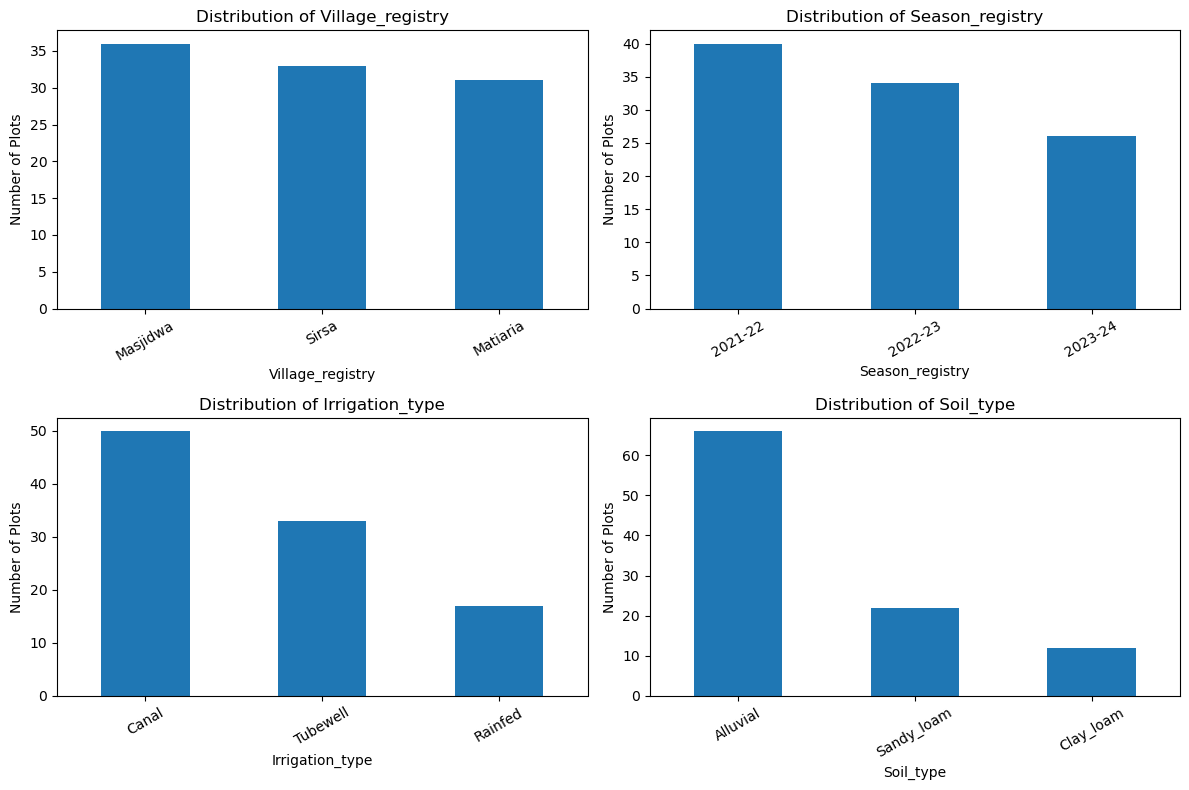

In [26]:
composition_vars = [
    "Village_registry",
    "Season_registry",
    "Irrigation_type",
    "Soil_type"
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), composition_vars):
    df[col].value_counts().plot(
        kind="bar",
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of Plots")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Numerical Distribution & Outlier Inspection

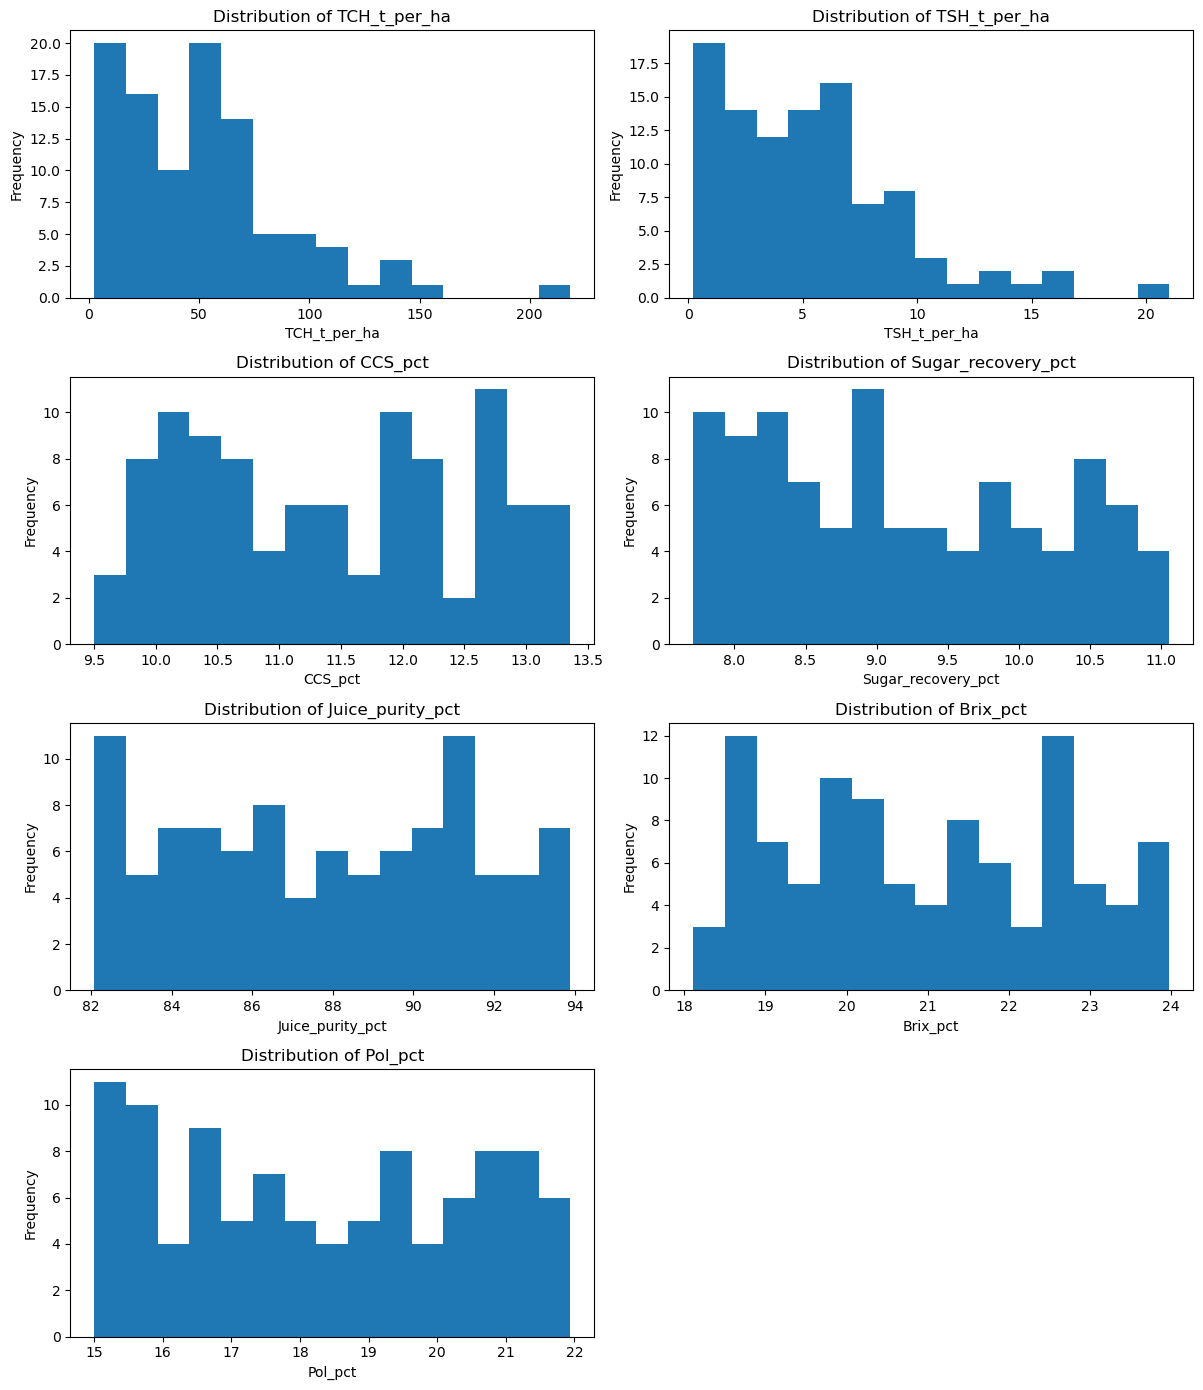

In [27]:
key_yield_vars = [
    "TCH_t_per_ha",
    "TSH_t_per_ha",
    "CCS_pct",
    "Sugar_recovery_pct",
    "Juice_purity_pct",
    "Brix_pct",
    "Pol_pct"
]
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, col in zip(axes, key_yield_vars):
    ax.hist(df[col], bins=15)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
# Hide unused subplot
axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [28]:
outlier_vars = [
    "TCH_t_per_ha",
    "TSH_t_per_ha",
    "CCS_pct",
    "Sugar_recovery_pct",
    "Juice_purity_pct",
    "Brix_pct",
    "Pol_pct"
]

outlier_summary = []

for col in outlier_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary.append({
        "Variable": col,
        "Q1": round(Q1, 3),
        "Q3": round(Q3, 3),
        "IQR": round(IQR, 3),
        "Lower_Bound": round(lower_bound, 3),
        "Upper_Bound": round(upper_bound, 3),
        "Outlier_Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,TCH_t_per_ha,22.050,70.418,48.368,-50.501,142.969,2
1,TSH_t_per_ha,2.184,7.007,4.823,-5.051,14.242,3
2,CCS_pct,10.428,12.302,1.875,7.615,15.115,0
3,Sugar_recovery_pct,8.335,9.972,1.637,5.879,12.429,0
4,Juice_purity_pct,84.708,90.842,6.135,75.505,100.045,0
5,Brix_pct,19.488,22.505,3.017,14.961,27.031,0
6,Pol_pct,16.428,20.212,3.785,10.750,25.890,0


In [29]:
for col in ["TCH_t_per_ha", "TSH_t_per_ha"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ][[
        "Plot_ID",
        "Village_registry",
        "Season_registry",
        "Cultivar",
        "Irrigation_type",
        "Soil_type",
        "TCH_t_per_ha",
        "TSH_t_per_ha",
        "CCS_pct",
        "GNDVI",
        "SPAD value",
        "Stress type"
    ]].sort_values(by=col, ascending=False)
    print("\n" + "=" * 70)
    print(f"Potential outliers for {col}")
    print(f"Upper IQR bound: {upper_bound:.3f}")
    print("=" * 70)
    display(outliers)


Potential outliers for TCH_t_per_ha
Upper IQR bound: 142.969


,Plot_ID,Village_registry,Season_registry,Cultivar,Irrigation_type,Soil_type,TCH_t_per_ha,TSH_t_per_ha,CCS_pct,GNDVI,SPAD value,Stress type
22,WC-023,Masjidwa,2022-23,CoS767,Tubewell,Sandy_loam,218.39,21.023,12.91,0.3915,70.25,Pest
57,WC-058,Sirsa,2021-22,CoVSI9,Canal,Clay_loam,154.36,16.537,10.21,0.3989,72.00,NaN



Potential outliers for TSH_t_per_ha
Upper IQR bound: 14.242


,Plot_ID,Village_registry,Season_registry,Cultivar,Irrigation_type,Soil_type,TCH_t_per_ha,TSH_t_per_ha,CCS_pct,GNDVI,SPAD value,Stress type
22,WC-023,Masjidwa,2022-23,CoS767,Tubewell,Sandy_loam,218.39,21.023,12.91,0.3915,70.25,Pest
57,WC-058,Sirsa,2021-22,CoVSI9,Canal,Clay_loam,154.36,16.537,10.21,0.3989,72.00,NaN
5,WC-006,Sirsa,2021-22,Co86032,Canal,Alluvial,136.25,15.845,13.09,0.5805,49.04,Disease


These are not obvious data-entry errors from the available variables.
>All three have complete yield-related values.

>Their TCH and TSH values are internally consistent: higher TCH corresponds to higher TSH.

>They belong to different cultivars, irrigation types, and soil types.

WC-023 has a recorded Pest stress, but we should not automatically claim that the stress explains its high yield.
WC-006 has Disease stress, while WC-058 has no recorded stress type. Again, these are observations, not proof of causation.
Since the project contains only 100 plots, removing 3 observations would unnecessarily discard potentially meaningful agricultural variation.

In [30]:
evi_stats = df["EVI"].describe()
print(evi_stats)
Q1 = df["EVI"].quantile(0.25)
Q3 = df["EVI"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("\nIQR:", round(IQR, 3))
print("Lower bound:", round(lower_bound, 3))
print("Upper bound:", round(upper_bound, 3))
evi_outliers = df[
    (df["EVI"] < lower_bound) |
    (df["EVI"] > upper_bound)
][[
    "Plot_ID",
    "Village_registry",
    "Season_registry",
    "EVI",
    "GNDVI",
    "NDVI",
    "LSWI",
    "Canopy LAI est",
    "Chlorophyll est ug cm2"
]].sort_values("EVI", ascending=False)
print("\nPotential EVI outliers:")
display(evi_outliers)

count    100.000000
mean       1.104269
std        0.972000
min        0.270200
25%        0.553775
50%        0.856500
75%        1.202300
max        6.581800
Name: EVI, dtype: float64

IQR: 0.649
Lower bound: -0.419
Upper bound: 2.175

Potential EVI outliers:


,Plot_ID,Village_registry,Season_registry,EVI,GNDVI,NDVI,LSWI,Canopy LAI est,Chlorophyll est ug cm2
29,WC-030,Matiaria,2021-22,6.5818,0.2935,0.7428,0.0750,1.94,14.16
2,WC-003,Matiaria,2023-24,4.9820,0.3347,0.7982,0.0379,2.04,12.91
37,WC-038,Matiaria,2021-22,4.1139,0.4867,0.8652,0.6608,3.20,24.13
26,WC-027,Sirsa,2022-23,3.3360,0.4733,0.7861,0.2245,2.48,22.32
78,WC-079,Matiaria,2021-22,3.1099,0.3986,0.7315,0.3481,2.75,21.28
98,WC-099,Sirsa,2021-22,2.9718,0.3982,0.7654,0.5296,2.49,20.08
21,WC-022,Sirsa,2021-22,2.6513,0.3966,0.7078,0.5873,2.50,20.36
67,WC-068,Masjidwa,2022-23,2.3787,0.5180,0.8407,0.2094,3.03,21.43
73,WC-074,Masjidwa,2022-23,2.3346,0.2716,0.6790,0.2214,1.79,15.11
60,WC-061,Masjidwa,2022-23,2.2176,0.3079,0.6798,0.5145,1.77,9.96


There is an interesting pattern: several of these high-EVI observations have relatively low NDVI, GNDVI, LSWI, and/or chlorophyll estimates. That means the high EVI values deserve further investigation rather than being treated as genuine vegetation extremes without checking their source.

### Relationship Analysis

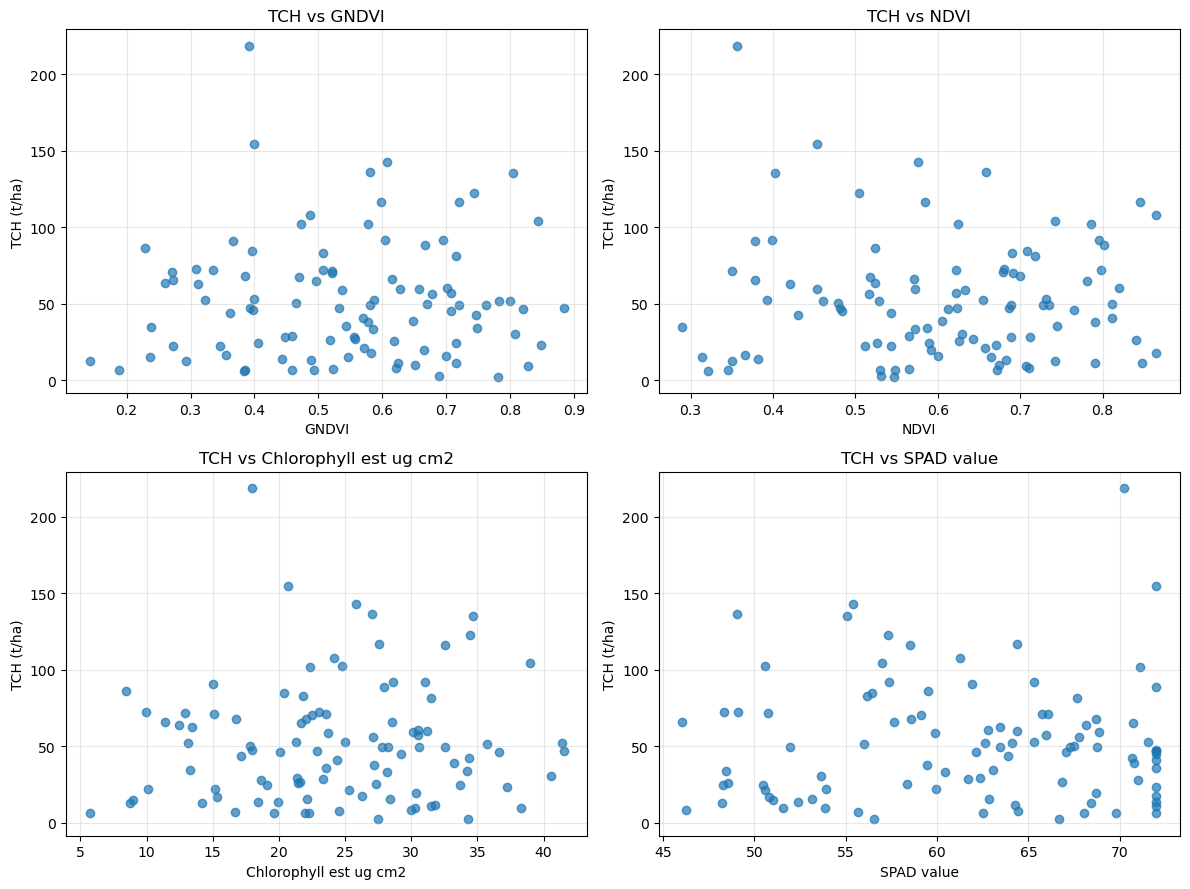

In [31]:
vegetation_vars = [
    "GNDVI",
    "NDVI",
    "Chlorophyll est ug cm2",
    "SPAD value"
]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for ax, col in zip(axes, vegetation_vars):
    ax.scatter(df[col], df["TCH_t_per_ha"], alpha=0.7)
    ax.set_title(f"TCH vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("TCH (t/ha)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
correlation_vars = [
    "TCH_t_per_ha",
    "GNDVI",
    "NDVI",
    "Chlorophyll est ug cm2",
    "SPAD value"
]
correlation_matrix = df[correlation_vars].corr(method="pearson")
display(correlation_matrix.round(3))

,TCH_t_per_ha,GNDVI,NDVI,Chlorophyll est ug cm2,SPAD value
TCH_t_per_ha,1.000,0.032,-0.020,0.044,0.018
GNDVI,0.032,1.000,0.333,0.973,0.040
NDVI,-0.020,0.333,1.000,0.320,0.080
Chlorophyll est ug cm2,0.044,0.973,0.320,1.000,0.056
SPAD value,0.018,0.040,0.080,0.056,1.000


### Nutrient–Vegetation Relationship

In [33]:
nitrogen_vars = [
    "N content pct DW",
    "N fertiliser kg ha"
]
vegetation_vars = [
    "GNDVI",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "Chlorophyll SPAD"
]
nitrogen_corr = df[
    nitrogen_vars + vegetation_vars
].corr(method="pearson")
display(nitrogen_corr.round(3))

,N content pct DW,N fertiliser kg ha,GNDVI,Chlorophyll est ug cm2,SPAD value,Chlorophyll SPAD
N content pct DW,1.000,-0.106,-0.112,-0.097,0.896,0.933
N fertiliser kg ha,-0.106,1.000,-0.024,-0.037,-0.069,-0.058
GNDVI,-0.112,-0.024,1.000,0.973,0.040,-0.100
Chlorophyll est ug cm2,-0.097,-0.037,0.973,1.000,0.056,-0.089
SPAD value,0.896,-0.069,0.040,0.056,1.000,0.939
Chlorophyll SPAD,0.933,-0.058,-0.100,-0.089,0.939,1.000


#### Important findings
- content and SPAD value are strongly related (r = 0.896).
- content and Chlorophyll SPAD are very strongly related (r = 0.933).
- content has almost no linear relationship with GNDVI or the chlorophyll estimate.
- fertiliser rate has almost no linear relationship with any of these vegetation/chlorophyll indicators.

The strong relationships between N content and the two SPAD measurements suggest that SPAD-type measurements capture nitrogen/chlorophyll-related variation much more directly in this dataset than GNDVI does.
These are correlations, so we should not interpret them as causal relationships.

In [34]:
phosphorus_vars = [
    "P content pct DW",
    "P fertiliser kg ha"
]
vegetation_vars = [
    "GNDVI",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "Chlorophyll SPAD"
]
phosphorus_corr = df[
    phosphorus_vars + vegetation_vars
].corr(method="pearson")
display(phosphorus_corr.round(3))

,P content pct DW,P fertiliser kg ha,GNDVI,Chlorophyll est ug cm2,SPAD value,Chlorophyll SPAD
P content pct DW,1.000,0.040,-0.122,-0.150,0.063,0.074
P fertiliser kg ha,0.040,1.000,0.016,0.051,-0.084,-0.092
GNDVI,-0.122,0.016,1.000,0.973,0.040,-0.100
Chlorophyll est ug cm2,-0.150,0.051,0.973,1.000,0.056,-0.089
SPAD value,0.063,-0.084,0.040,0.056,1.000,0.939
Chlorophyll SPAD,0.074,-0.092,-0.100,-0.089,0.939,1.000


### Interpretation
- content does not show a meaningful linear relationship with the vegetation/chlorophyll indicators in this dataset.
- fertiliser rate also shows essentially no linear association with these indicators.
- This contrasts with nitrogen, where N content had strong correlations with the SPAD-based measurements.
- The GNDVI ↔ Chlorophyll estimate and SPAD value ↔ Chlorophyll SPAD correlations appearing again are expected because those relationships are properties of the underlying variables, not specifically phosphorus relationships.

In [35]:
potassium_vars = [
    "K content pct DW",
    "K fertiliser kg ha"
]

vegetation_vars = [
    "GNDVI",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "Chlorophyll SPAD"
]

potassium_corr = df[
    potassium_vars + vegetation_vars
].corr(method="pearson")

display(potassium_corr.round(3))

,K content pct DW,K fertiliser kg ha,GNDVI,Chlorophyll est ug cm2,SPAD value,Chlorophyll SPAD
K content pct DW,1.000,0.120,0.201,0.245,0.094,0.035
K fertiliser kg ha,0.120,1.000,-0.007,0.041,0.172,0.123
GNDVI,0.201,-0.007,1.000,0.973,0.040,-0.100
Chlorophyll est ug cm2,0.245,0.041,0.973,1.000,0.056,-0.089
SPAD value,0.094,0.172,0.040,0.056,1.000,0.939
Chlorophyll SPAD,0.035,0.123,-0.100,-0.089,0.939,1.000


Interpretation
- K content has weak positive relationships with GNDVI (r = 0.201) and the chlorophyll estimate (r = 0.245).
- Its relationships with the two SPAD measurements are very weak.
- K fertiliser rate has essentially no linear relationship with GNDVI or chlorophyll estimate.
- Therefore, unlike N content, potassium does not show a strong linear association with the SPAD/chlorophyll indicators in this dataset.
- Again, these correlations do not establish causation.

### Nutrient classes vs crop yield

In [36]:
nutrient_yield_summary = pd.DataFrame({
    "N class - TCH": df.groupby("N class")["TCH_t_per_ha"].mean(),
    "N class - TSH": df.groupby("N class")["TSH_t_per_ha"].mean(),
    "P class - TCH": df.groupby("P class")["TCH_t_per_ha"].mean(),
    "P class - TSH": df.groupby("P class")["TSH_t_per_ha"].mean(),
    "K class - TCH": df.groupby("K class")["TCH_t_per_ha"].mean(),
    "K class - TSH": df.groupby("K class")["TSH_t_per_ha"].mean()
})
display(nutrient_yield_summary.round(3))

,N class - TCH,N class - TSH,P class - TCH,P class - TSH,K class - TCH,K class - TSH
Adequate,50.978,5.282,56.679,5.806,53.886,5.487
Deficient,60.357,5.934,24.305,2.290,17.953,1.962
Excess,51.067,5.100,39.993,4.070,48.673,5.072


In [37]:
print("N class counts:")
display(df["N class"].value_counts())
print("\nP class counts:")
display(df["P class"].value_counts())
print("\nK class counts:")
display(df["K class"].value_counts())

N class counts:


N class
Adequate     70
Excess       19
Deficient    11
Name: count, dtype: int64


P class counts:


P class
Adequate     74
Excess       24
Deficient     2
Name: count, dtype: int64


K class counts:


K class
Adequate     82
Excess       15
Deficient     3
Name: count, dtype: int64

"Yield varied across nutrient-class groups, but interpretation was affected by class imbalance. Nitrogen classes had comparatively more observations, whereas phosphorus- and potassium-deficient groups contained only 2 and 3 plots respectively. Therefore, class-wise yield differences for P and K deficiency were treated as exploratory observations rather than general conclusions."

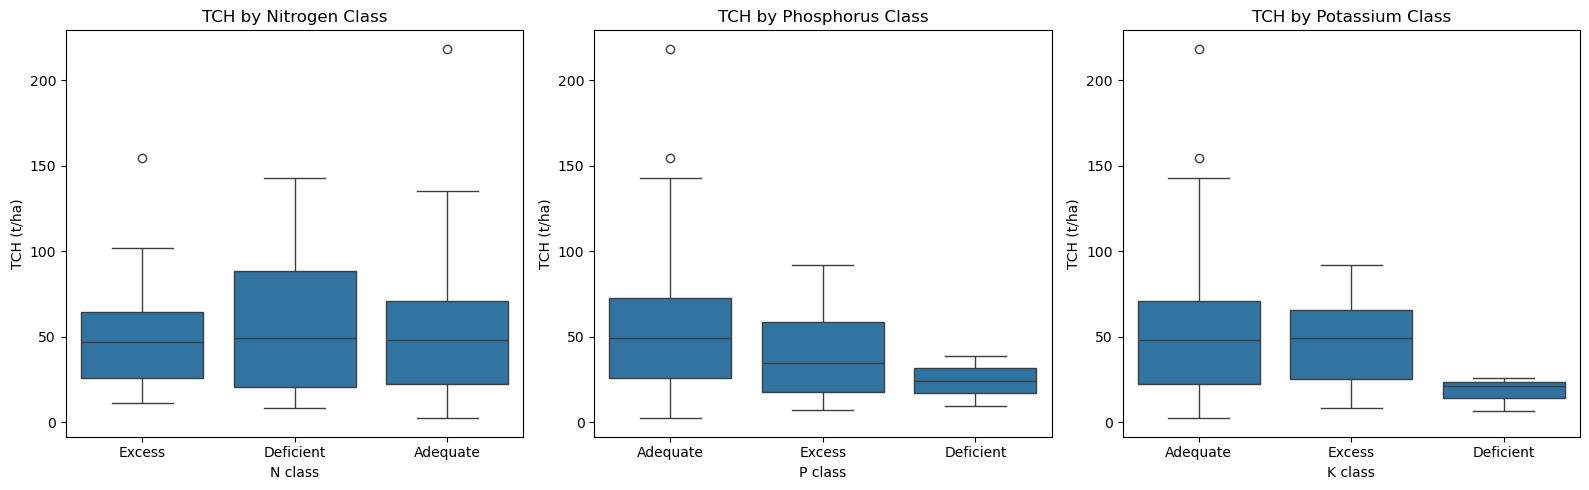

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="N class", y="TCH_t_per_ha", ax=axes[0])
axes[0].set_title("TCH by Nitrogen Class")
axes[0].set_xlabel("N class")
axes[0].set_ylabel("TCH (t/ha)")

sns.boxplot(data=df, x="P class", y="TCH_t_per_ha", ax=axes[1])
axes[1].set_title("TCH by Phosphorus Class")
axes[1].set_xlabel("P class")
axes[1].set_ylabel("TCH (t/ha)")

sns.boxplot(data=df, x="K class", y="TCH_t_per_ha", ax=axes[2])
axes[2].set_title("TCH by Potassium Class")
axes[2].set_xlabel("K class")
axes[2].set_ylabel("TCH (t/ha)")

plt.tight_layout()
plt.show()

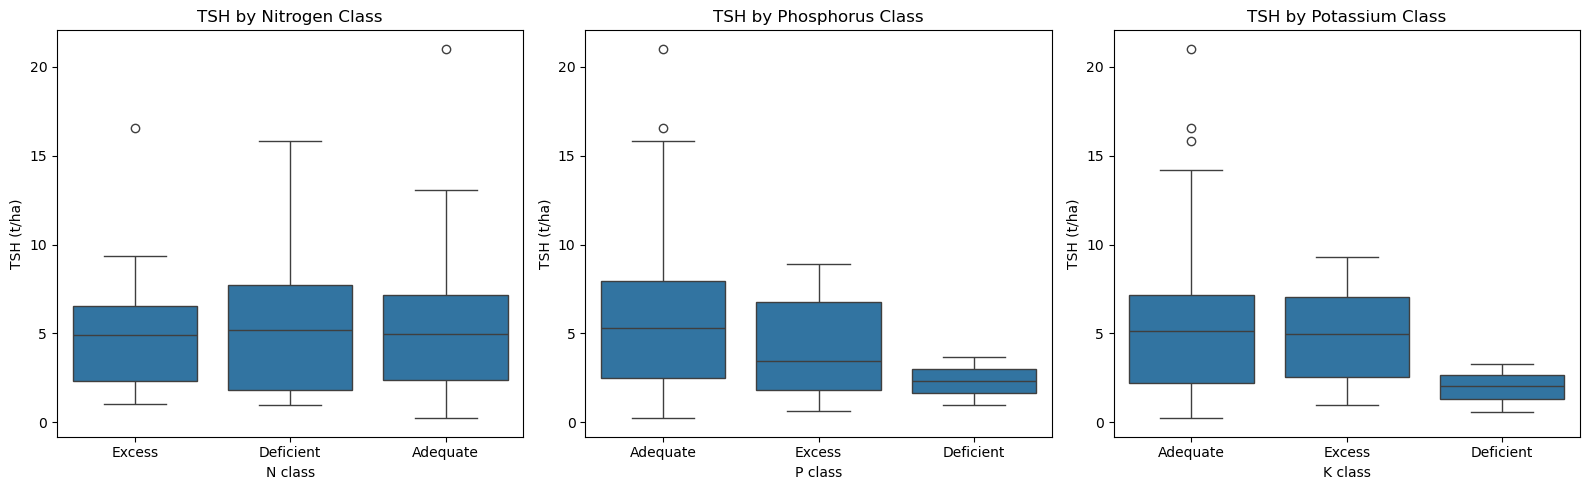

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="N class", y="TSH_t_per_ha", ax=axes[0])
axes[0].set_title("TSH by Nitrogen Class")
axes[0].set_xlabel("N class")
axes[0].set_ylabel("TSH (t/ha)")

sns.boxplot(data=df, x="P class", y="TSH_t_per_ha", ax=axes[1])
axes[1].set_title("TSH by Phosphorus Class")
axes[1].set_xlabel("P class")
axes[1].set_ylabel("TSH (t/ha)")

sns.boxplot(data=df, x="K class", y="TSH_t_per_ha", ax=axes[2])
axes[2].set_title("TSH by Potassium Class")
axes[2].set_xlabel("K class")
axes[2].set_ylabel("TSH (t/ha)")

plt.tight_layout()
plt.show()

#### Conclusion
Nutrient classes show differences in yield distributions, but interpretation is constrained by substantial class imbalance, particularly for P- and K-deficient groups. The observed differences should therefore be treated as exploratory rather than causal conclusions.

### Weather and stress analysis

In [40]:
weather_vars = [
    "Precip_growth_phase_mm",
    "Dry_spell_days_gt5",
    "Wet_days_gt10mm",
    "Max_1day_precip_mm",
    "SPI_3month"
]

yield_vars = [
    "TCH_t_per_ha",
    "TSH_t_per_ha"
]

weather_yield_corr = df[
    weather_vars + yield_vars
].corr(method="pearson")

display(weather_yield_corr.round(3))

,Precip_growth_phase_mm,Dry_spell_days_gt5,Wet_days_gt10mm,Max_1day_precip_mm,SPI_3month,TCH_t_per_ha,TSH_t_per_ha
Precip_growth_phase_mm,1.000,-0.006,0.094,-0.018,-0.144,0.004,0.027
Dry_spell_days_gt5,-0.006,1.000,0.033,-0.095,0.050,-0.048,-0.056
Wet_days_gt10mm,0.094,0.033,1.000,0.086,-0.019,0.108,0.109
Max_1day_precip_mm,-0.018,-0.095,0.086,1.000,0.198,0.152,0.126
SPI_3month,-0.144,0.050,-0.019,0.198,1.000,-0.000,-0.029
TCH_t_per_ha,0.004,-0.048,0.108,0.152,-0.000,1.000,0.984
TSH_t_per_ha,0.027,-0.056,0.109,0.126,-0.029,0.984,1.000


In [41]:
print("Drought flag:")
display(
    df.groupby("Drought_flag")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

print("\nExcess rain flag:")
display(
    df.groupby("Excess_rain_flag")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

Drought flag:


TCH_t_per_ha                 TSH_t_per_ha              
                    count    mean  median        count   mean median
Drought_flag                                                        
No                     94  52.353  47.160           94  5.372   4.92
Yes                     6  46.912  45.095            6  4.490   4.49


Excess rain flag:


TCH_t_per_ha                TSH_t_per_ha              
                        count    mean median        count   mean median
Excess_rain_flag                                                       
No                         99  52.214  47.27           99  5.332  4.959
Yes                         1  33.420  33.42            1  4.036  4.036

In [42]:
stress_yield_summary = (
    df.dropna(subset=["Stress type"])
      .groupby("Stress type")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

display(stress_yield_summary)

TCH_t_per_ha                 TSH_t_per_ha              
                           count    mean  median        count   mean median
Stress type                                                                
Disease                       10  60.426  43.860           10  6.310  3.932
Drought                       15  44.751  52.230           15  4.645  5.966
Heat                          12  39.055  40.645           12  4.034  3.933
Nutrient_deficiency            6  38.307  23.640            6  3.655  2.644
Pest                          16  68.744  62.315           16  7.089  5.958

#### Key observations

1. Pest

Pest-stress plots have relatively high observed mean and median TCH/TSH.
This is an important reminder that the Stress type field should not be interpreted as a simple measure of yield reduction.
A plot can have a recorded stress condition while still having high yield.

2. Disease

Disease has a relatively high mean TCH, but its median is much lower (43.86).
This indicates that the mean is influenced by some high-yield observations.

3. Drought

Drought has a mean TCH of 44.751, but its median is 52.230.
That difference indicates substantial variation within the drought group.

4. Heat

Heat has relatively low mean TCH (39.055) and TSH (4.034).

5. Nutrient deficiency

This group has the lowest mean TCH (38.307) and TSH (3.655).
But only 6 plots belong to this category, so this should remain an exploratory observation.

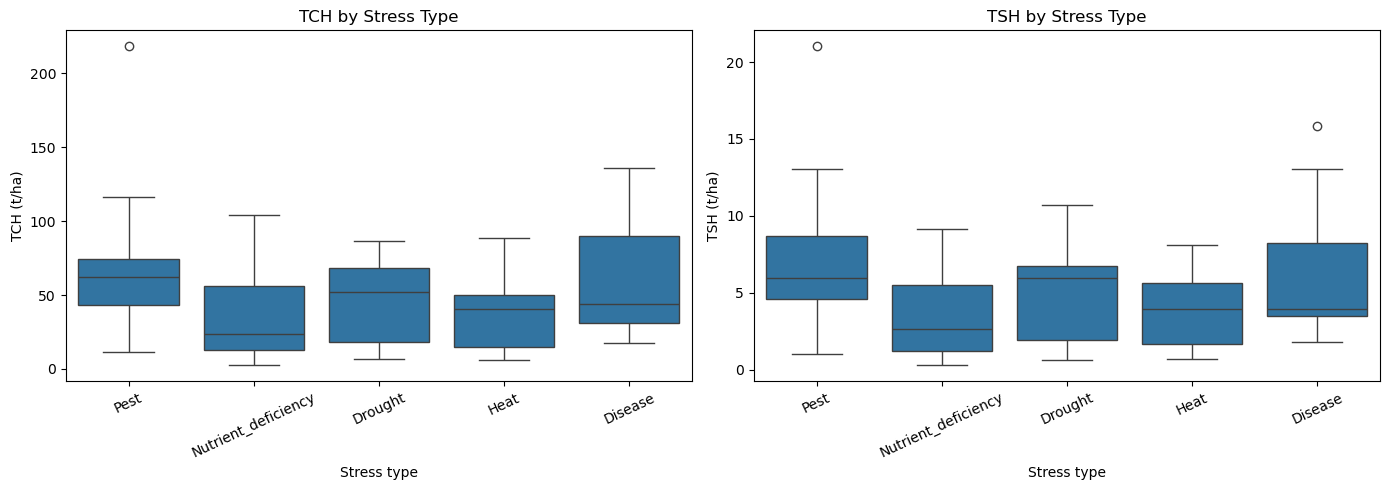

In [43]:
stress_df = df.dropna(subset=["Stress type"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=stress_df,
    x="Stress type",
    y="TCH_t_per_ha",
    ax=axes[0]
)
axes[0].set_title("TCH by Stress Type")
axes[0].set_xlabel("Stress type")
axes[0].set_ylabel("TCH (t/ha)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=stress_df,
    x="Stress type",
    y="TSH_t_per_ha",
    ax=axes[1]
)
axes[1].set_title("TSH by Stress Type")
axes[1].set_xlabel("Stress type")
axes[1].set_ylabel("TSH (t/ha)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

#### Conclusion
Yield distributions differed across recorded stress categories, with substantial within-category variation. Because stress classifications were incomplete and some categories had relatively few observations, these patterns are treated as exploratory associations rather than evidence of causal yield effects.

### Management and site factors vs yield

In [44]:
irrigation_yield = (
    df.groupby("Irrigation_type")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

display(irrigation_yield)

TCH_t_per_ha                TSH_t_per_ha              
                       count    mean median        count   mean median
Irrigation_type                                                       
Canal                     50  48.763  46.68           50  5.143  4.732
Rainfed                   17  46.604  38.89           17  4.601  3.925
Tubewell                  33  59.765  52.02           33  5.956  5.242

In [45]:
soil_yield = (
    df.groupby("Soil_type")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

display(soil_yield)

TCH_t_per_ha                 TSH_t_per_ha              
                  count    mean  median        count   mean median
Soil_type                                                         
Alluvial             66  50.915  47.160           66  5.339  4.920
Clay_loam            12  50.129  28.695           12  5.034  3.060
Sandy_loam           22  56.395  52.805           22  5.416  5.624

In [46]:
cultivar_yield = (
    df.groupby("Cultivar")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

display(cultivar_yield)

TCH_t_per_ha                 TSH_t_per_ha              
                count    mean  median        count   mean median
Cultivar                                                        
Co0238             22  54.546  48.265           22  5.413  4.885
Co86032            25  41.521  28.180           25  4.362  2.738
CoJ64              14  56.312  59.185           14  5.765  6.073
CoS767             22  53.955  48.625           22  5.541  5.084
CoVSI9             17  58.190  56.180           17  5.951  5.853

Cultivar-wise analysis showed variation in observed TCH and TSH across the five cultivars. CoVSI9 showed a relatively high mean yield, while Co86032 showed lower mean and median yields with greater difference between them. These differences are exploratory and may also reflect other environmental and management factors.

In [47]:
season_yield = (
    df.groupby("Season_registry")[["TCH_t_per_ha", "TSH_t_per_ha"]]
      .agg(["count", "mean", "median"])
      .round(3)
)

display(season_yield)

TCH_t_per_ha                 TSH_t_per_ha              
                       count    mean  median        count   mean median
Season_registry                                                        
2021-22                   40  48.647  44.805           40  5.173  4.848
2022-23                   34  55.699  50.850           34  5.479  5.024
2023-24                   26  52.423  46.670           26  5.335  4.960

Season-wise analysis showed variation in TCH and TSH across the three seasons. The 2022–23 season had the highest observed mean and median values for both TCH and TSH, while 2021–22 had the lowest observed values. These differences are exploratory and may be influenced by weather, management, cultivar, and other factors.

### Selected Correlation Heatmap.

In [48]:
#Selected correlation analysis

correlation_vars = [
    "TCH_t_per_ha",
    "TSH_t_per_ha",
    "CCS_pct",
    "Sugar_recovery_pct",
    "Brix_pct",
    "GNDVI",
    "NDVI",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "N content pct DW",
    "P content pct DW",
    "K content pct DW",
    "Precip_growth_phase_mm",
    "Dry_spell_days_gt5",
    "SPI_3month"
]

corr_matrix = df[correlation_vars].corr(method="pearson")

display(corr_matrix.round(3))

,TCH_t_per_ha,TSH_t_per_ha,CCS_pct,Sugar_recovery_pct,Brix_pct,GNDVI,NDVI,Chlorophyll est ug cm2,SPAD value,N content pct DW,P content pct DW,K content pct DW,Precip_growth_phase_mm,Dry_spell_days_gt5,SPI_3month
TCH_t_per_ha,1.000,0.984,0.066,0.021,0.204,0.032,-0.020,0.044,0.018,-0.049,-0.149,0.089,0.004,-0.048,-0.000
TSH_t_per_ha,0.984,1.000,0.080,0.011,0.223,0.006,-0.023,0.017,0.032,-0.033,-0.148,0.091,0.027,-0.056,-0.029
CCS_pct,0.066,0.080,1.000,0.028,-0.159,0.231,-0.061,0.228,0.004,-0.055,-0.023,-0.112,0.048,0.077,-0.019
Sugar_recovery_pct,0.021,0.011,0.028,1.000,0.021,-0.036,-0.112,-0.056,0.018,0.035,0.179,-0.002,-0.102,0.200,0.206
Brix_pct,0.204,0.223,-0.159,0.021,1.000,-0.050,-0.092,-0.072,0.044,0.035,-0.057,0.124,-0.059,-0.124,-0.114
GNDVI,0.032,0.006,0.231,-0.036,-0.050,1.000,0.333,0.973,0.040,-0.112,-0.122,0.201,0.085,-0.108,-0.050
NDVI,-0.020,-0.023,-0.061,-0.112,-0.092,0.333,1.000,0.320,0.080,0.087,-0.085,0.088,0.009,-0.032,0.050
Chlorophyll est ug cm2,0.044,0.017,0.228,-0.056,-0.072,0.973,0.320,1.000,0.056,-0.097,-0.150,0.245,0.110,-0.078,-0.039
SPAD value,0.018,0.032,0.004,0.018,0.044,0.040,0.080,0.056,1.000,0.896,0.063,0.094,0.162,-0.026,-0.223
N content pct DW,-0.049,-0.033,-0.055,0.035,0.035,-0.112,0.087,-0.097,0.896,1.000,0.051,0.035,0.157,-0.001,-0.228


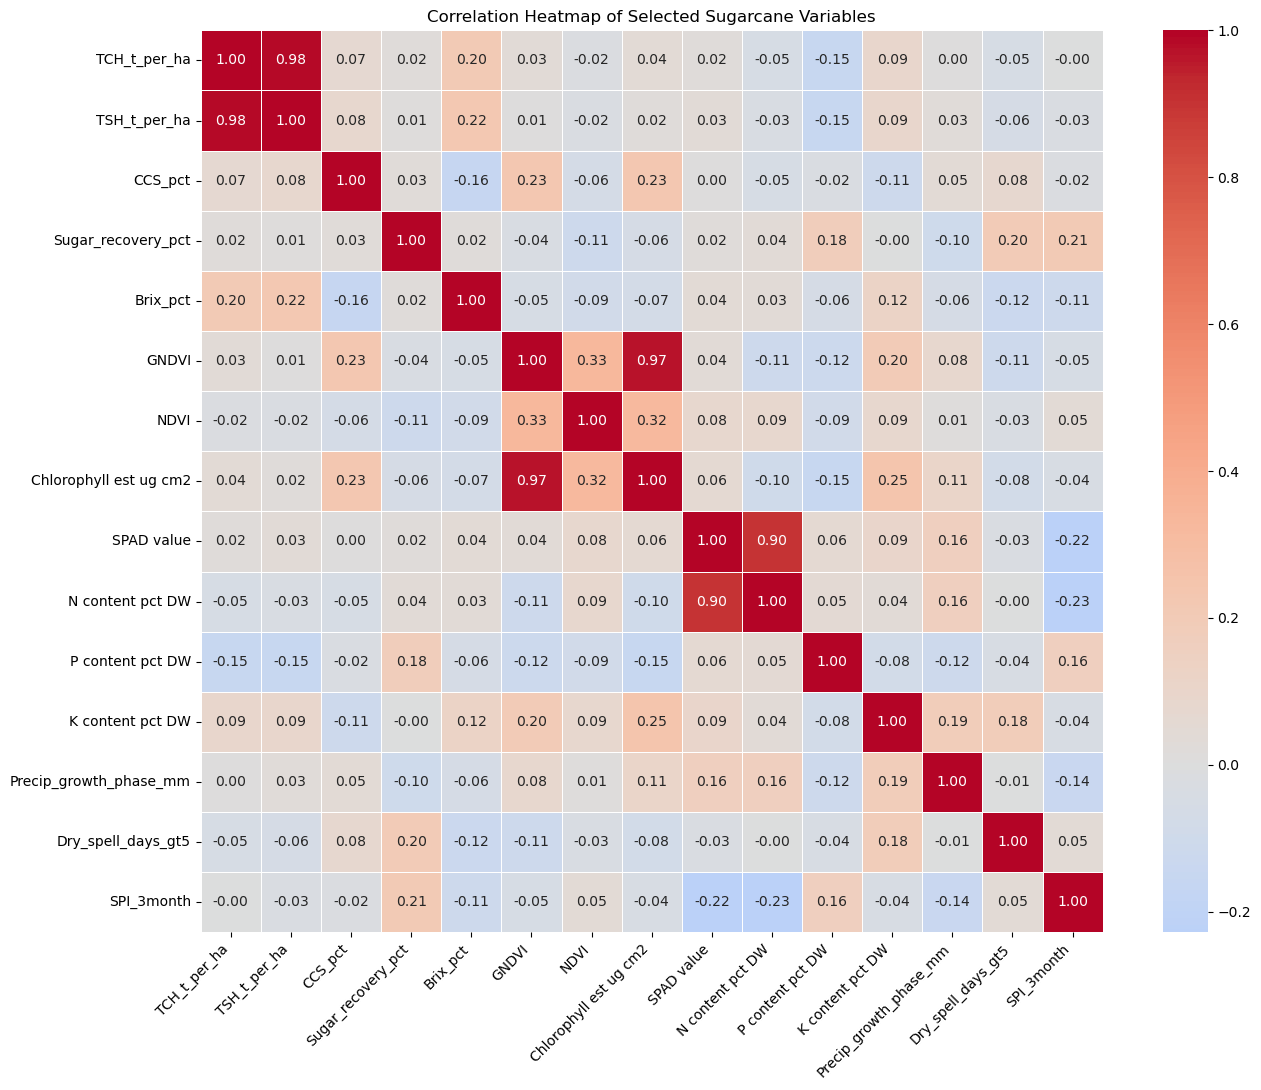

In [49]:
#Selected correlation heatmap

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Selected Sugarcane Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

### Integrated Analysis

In [50]:
#Integrated analysis summary

integrated_vars = [
    "TCH_t_per_ha",
    "TSH_t_per_ha",
    "GNDVI",
    "NDVI",
    "Chlorophyll est ug cm2",
    "SPAD value",
    "N content pct DW",
    "P content pct DW",
    "K content pct DW",
    "Precip_growth_phase_mm",
    "Dry_spell_days_gt5",
    "SPI_3month"
]

integrated_corr = df[integrated_vars].corr(method="pearson")

# Show only relationships with absolute correlation >= 0.20
stronger_relationships = (
    integrated_corr.where(
        np.triu(np.ones(integrated_corr.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

stronger_relationships.columns = ["Variable 1", "Variable 2", "Correlation"]

stronger_relationships = (
    stronger_relationships[
        stronger_relationships["Correlation"].abs() >= 0.20
    ]
    .sort_values("Correlation", key=abs, ascending=False)
    .round(3)
)

display(stronger_relationships)

,Variable 1,Variable 2,Correlation
0,TCH_t_per_ha,TSH_t_per_ha,0.984
22,GNDVI,Chlorophyll est ug cm2,0.973
45,SPAD value,N content pct DW,0.896
21,GNDVI,NDVI,0.333
30,NDVI,Chlorophyll est ug cm2,0.320
41,Chlorophyll est ug cm2,K content pct DW,0.245
55,N content pct DW,SPI_3month,-0.228
50,SPAD value,SPI_3month,-0.223
26,GNDVI,K content pct DW,0.201


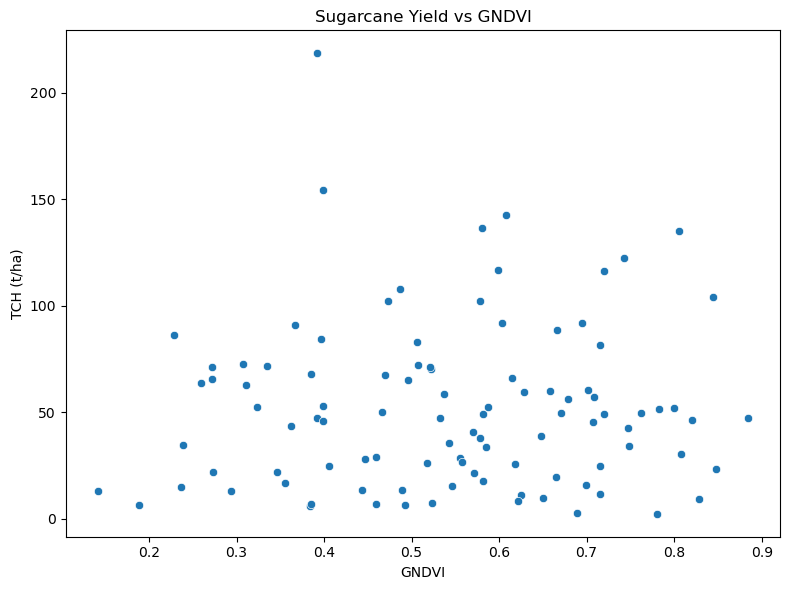

In [53]:
#Yield vs vegetation relationship

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="GNDVI",
    y="TCH_t_per_ha"
)

plt.title("Sugarcane Yield vs GNDVI")
plt.xlabel("GNDVI")
plt.ylabel("TCH (t/ha)")
plt.tight_layout()

plt.show()

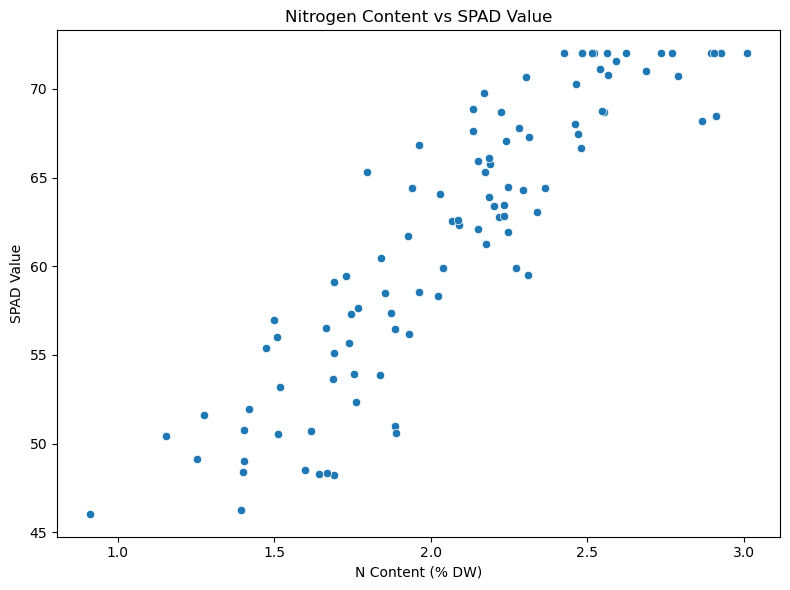

In [55]:
#Nitrogen content vs SPAD value

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="N content pct DW",
    y="SPAD value"
)

plt.title("Nitrogen Content vs SPAD Value")
plt.xlabel("N Content (% DW)")
plt.ylabel("SPAD Value")
plt.tight_layout()

plt.show()

“Nitrogen content showed a strong positive association with SPAD value (r = 0.896), indicating that plots with higher measured nitrogen content generally showed higher SPAD readings.”

In [56]:
#Final key analytical findings

final_findings = pd.DataFrame({
    "Analysis": [
        "TCH vs TSH",
        "GNDVI vs Chlorophyll estimate",
        "N content vs SPAD",
        "TCH vs GNDVI",
        "TCH vs Growth-phase precipitation",
        "TCH vs Dry-spell days"
    ],
    "Pearson_r": [
        0.984,
        0.973,
        0.896,
        0.032,
        0.004,
        -0.048
    ],
    "Interpretation": [
        "Very strong positive association",
        "Very strong positive association",
        "Strong positive association",
        "Very weak linear association",
        "Negligible linear association",
        "Very weak negative association"
    ]
})

display(final_findings)

,Analysis,Pearson_r,Interpretation
0,TCH vs TSH,0.984,Very strong positive association
1,GNDVI vs Chlorophyll estimate,0.973,Very strong positive association
2,N content vs SPAD,0.896,Strong positive association
3,TCH vs GNDVI,0.032,Very weak linear association
4,TCH vs Growth-phase precipitation,0.004,Negligible linear association
5,TCH vs Dry-spell days,-0.048,Very weak negative association


In [57]:
# Final EDA conclusions

eda_conclusions = [
    "TCH and TSH showed a very strong positive association (r = 0.984).",
    
    "GNDVI and estimated chlorophyll showed a very strong positive association (r = 0.973), indicating a strong relationship between vegetation vigour and estimated chlorophyll in the dataset.",
    
    "Nitrogen content and SPAD value showed a strong positive association (r = 0.896).",
    
    "TCH and GNDVI showed a very weak linear association (r = 0.032), indicating that GNDVI alone did not explain the observed variation in cane yield.",
    
    "Growth-phase precipitation showed a negligible linear association with TCH (r = 0.004), while dry-spell days showed a very weak negative association (r = -0.048).",
    
    "Yield varied across irrigation type, soil type, cultivar, and season groups, but these are observational comparisons and may reflect multiple interacting factors."
]

for i, conclusion in enumerate(eda_conclusions, 1):
    print(f"{i}. {conclusion}\n")

1. TCH and TSH showed a very strong positive association (r = 0.984).

2. GNDVI and estimated chlorophyll showed a very strong positive association (r = 0.973), indicating a strong relationship between vegetation vigour and estimated chlorophyll in the dataset.

3. Nitrogen content and SPAD value showed a strong positive association (r = 0.896).

4. TCH and GNDVI showed a very weak linear association (r = 0.032), indicating that GNDVI alone did not explain the observed variation in cane yield.

5. Growth-phase precipitation showed a negligible linear association with TCH (r = 0.004), while dry-spell days showed a very weak negative association (r = -0.048).

6. Yield varied across irrigation type, soil type, cultivar, and season groups, but these are observational comparisons and may reflect multiple interacting factors.



# Final Analysis Summary

## Objective

The objective of this analysis was to explore the relationships between sugarcane yield, sugar quality, vegetation indices, nutrient status, weather conditions, stress factors, and management/site characteristics using the integrated Master Sheet.

## Dataset

The final Master Sheet contained 100 unique sugarcane plots and 126 variables derived from eight source datasets covering plot information, yield, precipitation, nitrogen, phosphorus, potassium, vegetation indices, and chlorophyll measurements.

## Data Quality

The dataset contained 241 missing cells, representing approximately 1.91% of all cells. Missingness was concentrated in the Notes fields and Stress type. Missing Stress type values were retained as missing and were not interpreted as absence of stress.

Potential outliers in TCH, TSH, and EVI were investigated. No observations were removed solely on the basis of statistical outlier detection because the identified observations did not provide sufficient evidence of data-entry errors.

## Exploratory Data Analysis

The analysis included:

- Dataset composition and categorical distributions
- Descriptive statistics
- Yield and sugar-quality distributions
- Outlier investigation
- Vegetation and chlorophyll relationships
- Nitrogen, phosphorus, and potassium analysis
- Weather and precipitation analysis
- Stress analysis
- Irrigation and soil comparisons
- Cultivar and seasonal comparisons
- Selected Pearson correlation analysis

## Key Findings

1. TCH and TSH showed a very strong positive association (r = 0.984).

2. GNDVI and estimated chlorophyll showed a very strong positive association (r = 0.973).

3. Nitrogen content and SPAD value showed a strong positive association (r = 0.896).

4. TCH and GNDVI showed a very weak linear association (r = 0.032), indicating that GNDVI alone did not explain the observed variation in cane yield.

5. Growth-phase precipitation and dry-spell days showed very weak or negligible linear associations with TCH.

6. Yield varied across irrigation type, soil type, cultivar, and season groups. These comparisons are observational and may reflect multiple interacting factors.

## Limitations

- The analysis is based on 100 plots in the final integrated dataset.
- Stress type was missing for 41 plots.
- Some nutrient categories had very small sample sizes, particularly P-deficient and K-deficient groups.
- Excess-rain observations were extremely limited.
- Pearson correlation measures linear association and does not establish causation.
- Differences between management, cultivar, soil, and season groups should not be interpreted as causal effects without further controlled analysis.

## Conclusion

The analysis demonstrates a complete data-analysis workflow from multi-source data integration and preprocessing to exploratory analysis, statistical association analysis, visualization, and interpretation. The results highlight strong relationships among yield components, vegetation indicators, and nitrogen-related physiological measurements, while also showing that individual vegetation or weather variables alone did not explain all observed yield variation.

In [71]:
# Final Notebook 2 verification
import os
print("==========================================")
print("NOTEBOOK 2 - FINAL VERIFICATION")
print("==========================================")

print(f"Master Sheet shape: {df.shape}")
print(f"Unique Plot IDs: {df['Plot_ID'].nunique()}")
print(f"Total missing cells: {df.isna().sum().sum()}")
print(f"Final figures saved: {len(os.listdir('../outputs/figures'))}")
print(f"Final tables saved: {len(os.listdir('../outputs/tables'))}")

print("\nNotebook 2 analysis completed successfully.")

NOTEBOOK 2 - FINAL VERIFICATION
Master Sheet shape: (100, 126)
Unique Plot IDs: 100
Total missing cells: 241
Final figures saved: 6
Final tables saved: 8

Notebook 2 analysis completed successfully.
